### INITIALIZATION

In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"

In [2]:
import math
import random

In [3]:
from gensim.models import Word2Vec

In [4]:
from sklearn.metrics import f1_score

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from torch.amp import autocast, GradScaler

torch._inductor.config.triton.cudagraph_skip_dynamic_graphs=True
torch.backends.fp32_precision = "tf32"
torch.backends.cudnn.fp32_precision = "tf32"
torch.backends.cudnn.rnn.fp32_precision = "tf32"

In [6]:
from time import perf_counter

In [7]:
import pandas as pd
import numpy as np

In [8]:
assert torch.cuda.is_available()
device = torch.device("cuda")
print(f"Device: {device}")

Device: cuda


In [9]:
from nn_lstm_preprocessing import get_preprocessed_data, EMBEDDING_MODEL_PATH

### PREPARE DATASET FOR NEURAL NETWORK

In [10]:
embedding_model = Word2Vec.load(EMBEDDING_MODEL_PATH)

In [11]:
data = get_preprocessed_data()

Processed chunks: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 

In [12]:
# Shuffle dataset randomly
data = data.sample(frac=1, random_state=0)
data.reset_index(inplace=True, drop=True)

In [13]:
# GROUP BY BUCKET SIZE
buckets = [0, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
data["bucket"] = pd.cut(data["content"].apply(lambda x: x.shape[0]), bins=buckets, labels=buckets[1:])

In [14]:
for bucket_size, group in data.groupby("bucket", observed=True):
    print(f"Length: {len(group)} Bucketsize: {bucket_size}")

Length: 8461 Bucketsize: 8
Length: 44657 Bucketsize: 16
Length: 68083 Bucketsize: 32
Length: 67885 Bucketsize: 64
Length: 134678 Bucketsize: 128
Length: 169273 Bucketsize: 256
Length: 226486 Bucketsize: 512
Length: 140931 Bucketsize: 1024
Length: 34300 Bucketsize: 2048
Length: 7074 Bucketsize: 4096
Length: 1549 Bucketsize: 8192
Length: 294 Bucketsize: 16384
Length: 7 Bucketsize: 32768


In [15]:
split_index1 = int(len(data)*0.8)
split_index2 = int(len(data)*0.9)

In [16]:
train_set = data.iloc[:split_index1]
val_set = data.iloc[split_index1:split_index2]
test_set = data.iloc[split_index2:]

In [17]:
print(len(train_set))
print(len(val_set))
print(len(test_set))

722942
90368
90368


In [18]:
# Custom sampler to prepare batches of articles with roughly same amount of tokens

class MySampler(Sampler):
    def __init__(self, groups, bucket_to_batch_size):
        self.groups = groups
        self.bucket_to_batch_size = bucket_to_batch_size

    def __iter__(self):
        batches = []
        
        for bucket_size, group_indices in self.groups.indices.items():    
            indices = list(group_indices)
            random.shuffle(indices)

            new_batch_size = self.bucket_to_batch_size[bucket_size]
            for i in range(0, len(indices), new_batch_size):
                batch = indices[i:i+new_batch_size]
                if batch:
                    batches.append(batch)

        random.shuffle(batches)
        
        yield from batches

    def __len__(self):
        return len(self.batches)

In [19]:
class ArticleDataset(Dataset):
    def __init__(self, df):
        self.data = df

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        articles = self.data["content"].iloc[idx]
        padded_articles = pad_sequence(articles.tolist(), batch_first=True)
        lengths = torch.tensor([a.size(0) for a in articles], dtype=torch.long).cpu()
        
        labels = self.data["type"].iloc[idx]
        labels_tensor = torch.from_numpy(labels.to_numpy(dtype=np.float32))

        # article_tensor = self.embedding(article)
        # label_tensor = torch.tensor([label], dtype=torch.float32)
        return padded_articles, lengths, labels_tensor

#### TRAIN, VALIDATION, TEST DATASETS

In [20]:
bucket_to_batch_size = {
    8: 512, 
    16: 512, 
    32: 512, 
    64: 512, 
    128: 512, 
    256: 512, 
    512: 256, 
    1024: 128, 
    2048: 64, 
    4096: 32, 
    8192: 16, 
    16384: 8, 
    32768: 4,
}

In [21]:
train_sampler = MySampler(train_set.groupby("bucket", observed=True), bucket_to_batch_size)

train_dataloader = DataLoader(
    ArticleDataset(train_set), 
    batch_size=1,
    sampler=train_sampler,
    num_workers=4,
    collate_fn=None, 
    pin_memory=True,
    persistent_workers=True,
)

In [22]:
val_sampler = MySampler(val_set.groupby("bucket", observed=True), bucket_to_batch_size)

val_dataloader = DataLoader(
    ArticleDataset(val_set), 
    batch_size=1,
    sampler=val_sampler,
    num_workers=4,
    collate_fn=None, 
    pin_memory=True,
    persistent_workers=True,
)

In [23]:
test_sampler = MySampler(test_set.groupby("bucket", observed=True), bucket_to_batch_size)

test_dataloader = DataLoader(
    ArticleDataset(test_set), 
    batch_size=1,
    sampler=test_sampler,
    num_workers=4,
    collate_fn=None, 
    pin_memory=True,
    persistent_workers=True,
)

### NN MODEL

In [27]:
class WordRNN(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, tagset_size=1):
        super(WordRNN, self).__init__()

        self.word_embeddings = nn.Embedding.from_pretrained(torch.tensor(embedding_model.wv.vectors))
        self.word_embeddings.weight.requires_grad = False
        
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, article_data, article_lengths):
        article_embeddings_tensor = self.word_embeddings(article_data)
        
        packed_data = pack_padded_sequence(article_embeddings_tensor, article_lengths, batch_first=True, enforce_sorted=False)
        output, (h_n, c_n) = self.lstm(article_embeddings_tensor)
        last_hidden = h_n[-1]

        logit = self.fc(last_hidden)

        return logit

In [28]:
model = WordRNN(128, 256)
# Embedding dim: 64
# Hidden dim: 128
# Number of LSTM layers: 2

model = model.to("cuda")
model = torch.compile(model, mode="max-autotune-no-cudagraphs")
model

OptimizedModule(
  (_orig_mod): WordRNN(
    (word_embeddings): Embedding(385220, 128)
    (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=256, out_features=1, bias=True)
  )
)

### TRAINING

In [29]:
scaler = GradScaler()

In [30]:
criterion = nn.BCEWithLogitsLoss(reduction="sum")
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [31]:
def train_one_batch(model, batch_articles, article_lengths, batch_labels):
    batch_articles = batch_articles.squeeze(0)
    article_lengths = article_lengths.squeeze(0)
    batch_labels = batch_labels.squeeze(0)

    optimizer.zero_grad(set_to_none=True)

    batch_articles = batch_articles.to(device, non_blocking=True)
    batch_labels = batch_labels.to(device, non_blocking=True)

    with autocast(device_type="cuda"):
        outputs = model(batch_articles, article_lengths).view(batch_labels.size(0))
        batch_loss = criterion(outputs, batch_labels)
    
    scaler.scale(batch_loss).backward()
        
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
        
    scaler.update()

    return batch_loss.item()

In [32]:
def evaluate_one_batch(model, batch_articles, article_lengths, batch_labels):
    batch_articles = batch_articles.squeeze(0)
    article_lengths = article_lengths.squeeze(0)
    batch_labels = batch_labels.squeeze(0)
    
    batch_articles = batch_articles.to(device, non_blocking=True)
    batch_labels = batch_labels.to(device, non_blocking=True)
    
    outputs = model(batch_articles, article_lengths).view(batch_labels.size(0))
    batch_loss = criterion(outputs, batch_labels)

    return batch_loss.item()

In [33]:
epoch_losses = []

In [34]:
start_time = perf_counter()
best_loss = np.inf
last_val_avg_loss = np.inf
best_model_state = None
epochs_since_last_improvement = 0

In [35]:
for epoch in range(0, 20):
    model.train()
    epoch_training_loss = 0.0
    epoch_training_samples = 0
    for index, (batch_articles, article_lengths, batch_labels) in enumerate(train_dataloader):
        batch_loss = train_one_batch(model, batch_articles, article_lengths, batch_labels)
        epoch_training_loss += batch_loss
        epoch_training_samples += batch_articles.shape[0]
            
    avg_epoch_training_loss = epoch_training_loss / epoch_training_samples

    
    model.eval()
    epoch_val_loss = 0.0
    epoch_val_samples = 0
    with torch.no_grad():
        for index, (batch_articles, article_lengths, batch_labels) in enumerate(val_dataloader):
            batch_loss = evaluate_one_batch(model, batch_articles, article_lengths, batch_labels)            
            epoch_val_loss += batch_loss
            epoch_val_samples += batch_articles.shape[0]

    avg_epoch_val_loss = epoch_val_loss / epoch_val_samples

    
    end_time = perf_counter()
    print(f"\nEpoch {epoch} avg training loss: {avg_epoch_training_loss:.3f}.")
    print(f"Epoch {epoch} avg eval loss: {avg_epoch_val_loss:.3f}. Changed {avg_epoch_val_loss - last_val_avg_loss:.3f}. Improved {avg_epoch_val_loss - best_loss:.3f}")
    print(f"Epoch {epoch} elapsed time: {end_time - start_time:.3f} seconds.")

    if avg_epoch_val_loss < best_loss:
        improvement = best_loss - avg_epoch_val_loss
        best_loss = avg_epoch_val_loss
        best_model_state = model.state_dict()

        if improvement > 0.001:
            epochs_since_last_improvement = 0
        else:
            epochs_since_last_improvement += 1
    else:
        epochs_since_last_improvement += 1
        
    if epochs_since_last_improvement == 4:
        print(f"Stopping early at epoch {epoch}")
        break
            
    last_val_avg_loss = avg_epoch_val_loss
    epoch_losses.append(avg_epoch_val_loss)
    start_time = end_time


Epoch 0 avg training loss: 86.598.
Epoch 0 avg eval loss: 72.478. Changed -inf. Improved -inf
Epoch 0 elapsed time: 292.571 seconds.

Epoch 1 avg training loss: 61.086.
Epoch 1 avg eval loss: 54.211. Changed -18.267. Improved -18.267
Epoch 1 elapsed time: 276.012 seconds.

Epoch 2 avg training loss: 50.650.
Epoch 2 avg eval loss: 47.138. Changed -7.073. Improved -7.073
Epoch 2 elapsed time: 267.331 seconds.

Epoch 3 avg training loss: 42.805.
Epoch 3 avg eval loss: 41.202. Changed -5.936. Improved -5.936
Epoch 3 elapsed time: 267.547 seconds.

Epoch 4 avg training loss: 37.112.
Epoch 4 avg eval loss: 35.646. Changed -5.556. Improved -5.556
Epoch 4 elapsed time: 279.782 seconds.

Epoch 5 avg training loss: 33.455.
Epoch 5 avg eval loss: 32.853. Changed -2.793. Improved -2.793
Epoch 5 elapsed time: 282.053 seconds.

Epoch 6 avg training loss: 30.513.
Epoch 6 avg eval loss: 30.890. Changed -1.963. Improved -1.963
Epoch 6 elapsed time: 268.114 seconds.

Epoch 7 avg training loss: 28.285.


In [36]:
torch.save(best_model_state, "../models/nn_model2.pth")

In [51]:
pd.Series(epoch_losses).to_csv("../data/nn_model2_loss.csv")

#### TESTING

In [ ]:
model.load_state_dict(torch.load("model2_25epoch.pth"))

In [37]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [203]:
torch.cuda.empty_cache()

In [183]:
for index, (batch_articles, article_lengths, batch_labels) in enumerate(test_dataloader):
    print(batch_articles.shape)
    print(article_lengths.shape)
    print(batch_labels.shape)
    break

torch.Size([1, 512, 16])
torch.Size([1, 512])
torch.Size([1, 512])


In [38]:
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for index, (batch_articles, article_lengths, batch_labels) in enumerate(test_dataloader):
        batch_articles = batch_articles.squeeze(0)
        article_lengths = article_lengths.squeeze(0)
        batch_labels = batch_labels.squeeze(0)

        batch_articles = batch_articles.to(device, non_blocking=True)

        output = model(batch_articles, article_lengths)

        probs = torch.sigmoid(output)
        prediction = (probs > 0.5).long().cpu()
        
        predictions.append(prediction)
        true_labels.append(batch_labels)

In [39]:
test_score = f1_score(torch.cat(true_labels), torch.cat(predictions), pos_label=1)
test_score

0.9469365488867927

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

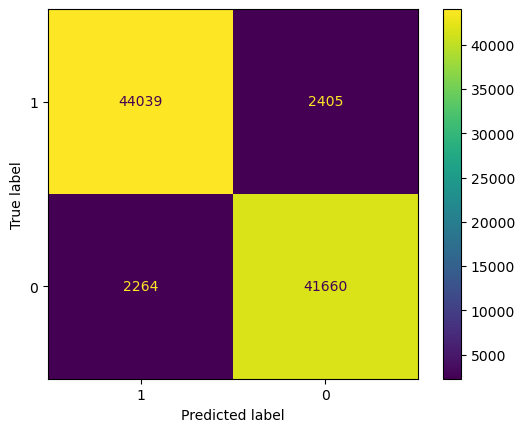

In [48]:
conf_ma = confusion_matrix(torch.cat(true_labels), torch.cat(predictions))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_ma, display_labels=[1,0])
disp.plot()